# Diagonal integration: [RNA, ATAC], every method

This notebook runs every method that has a variant for diagonal [RNA, ATAC] on `D27mini`: Conos, GLUE, MultiMAP, Portal, SCALEX, Seurat_v3, Seurat_v5, VIPCCA, iNMF, online_iNMF, scBridge, scJoint, sciCAN and uniPort. The [tutorial](https://dsichang.github.io/scMultiBench/tutorials/diagonal_rna_atac/) explains each step and runs iNMF and online_iNMF only.

Methods run on Linux. The environments are 9 envs, 18.9 GB to download on a CPU host, 26.1 GB on a GPU host.

## 1. Install

This cell installs `multibench-sc`. It keeps the numpy and pandas that are already installed, so Colab needs no restart.

<details>
<summary>Details</summary>

On Colab, choose a GPU runtime before you run the notebook: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, an environment that has a smaller CPU build gets that build, and training methods run slower.

</details>

In [1]:
import numpy, pandas
%pip install -q multibench-sc numpy=={numpy.__version__} pandas=={pandas.__version__}

Note: you may need to restart the kernel to use updated packages.


## 2. Download the data and the environments

In [2]:
import pandas as pd
import multibench as mtb

mtb.data.fetch("D27mini")

PosixPath('/tmp/mbverify/home/.cache/multibench/data')

In [3]:
METHODS = ["Conos", "GLUE", "MultiMAP", "Portal", "SCALEX", "Seurat_v3", "Seurat_v5",
           "VIPCCA", "iNMF", "online_iNMF", "scBridge", "scJoint", "sciCAN", "uniPort"]
envs = mtb.env.install(METHODS, dry_run=False)
pd.DataFrame(envs)[["env", "methods", "state"]]

,env,methods,state
0,scmb_torch,"[MultiMAP, SCALEX, scBridge, uniPort]",have
1,scmb_r,"[Conos, iNMF, online_iNMF]",have
2,glue,[GLUE],have
3,scmb_scican,[sciCAN],have
4,scmb_scjoint,[scJoint],have
5,scmb_seurat4b,[Seurat_v3],have
6,scmb_seurat5,[Seurat_v5],have
7,scmb_torch_v2,[Portal],have
8,scmb_vipcca27,[VIPCCA],have


## 3. Run the methods

In [4]:
res = mtb.run_all("D27mini", "diagonal", methods=METHODS,
                  out_dir="out/D27mini_all")
res.summary

[run_all] 4 more rows need files this folder does not have. mtb.scan shows them.


[run_all] Conos (diagonal/D27mini) ...


[run_all]   -> CHAIN_OK (42.0s) ARI 0.000


[run_all] GLUE (diagonal/D27mini) ...


[run_all]   GLUE reads the GENCODE v43 human annotation (gencode.v43.chr_patch_hapl_scaff.annotation.gtf.gz, 53 MB) from <repo_path>/tools_scripts/GLUE/.


...

[run_all] sciCAN (diagonal/D27mini) ...


[run_all]   -> CHAIN_OK (84.3s) ARI 0.469


[run_all] uniPort (diagonal/D27mini) ...


[run_all]   -> CHAIN_OK (462.9s) ARI 0.666


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,...,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note,caveat,reason
0,Conos,CHAIN_OK,42.0,embedding,"[6000, 2]",0,rna_cty.csv+atac_cty.csv,NaN,file_of_origin,2,...,0.4652,0.4555,0.0840,0.6777,0.8705,0.0564,0.2894,winner at chance,,
1,GLUE,CHAIN_OK,340.0,embedding,"[6000, 50]",0,rna_cty.csv+atac_cty.csv,0.0,file_of_origin,2,...,0.5928,0.5964,0.7128,0.9768,0.8606,0.9473,0.9060,None,GLUE reads the GENCODE v43 human annotation (g...,
2,MultiMAP,CHAIN_OK,23.1,embedding,"[6000, 2]",0,rna_cty.csv+atac_cty.csv,0.0,file_of_origin,2,...,0.5761,0.6287,0.6880,0.9831,0.7019,0.8763,0.8208,None,,
3,Portal,CHAIN_OK,43.6,embedding,"[6000, 20]",0,rna_cty.csv+atac_cty.csv,0.0,file_of_origin,2,...,0.5629,0.5841,0.8412,0.9873,0.8230,0.9833,0.4832,None,,
4,SCALEX,CHAIN_OK,261.4,embedding,"[6000, 10]",0,rna_cty.csv+atac_cty.csv,0.0,file_of_origin,2,...,0.5772,0.5922,0.6850,0.9885,0.7966,0.9795,0.1361,None,,
5,Seurat_v3,CHAIN_OK,51.3,embedding,"[6000, 50]",0,rna_cty.csv+atac_cty.csv,0.0,file_of_origin,2,...,0.5452,0.5898,0.8461,0.9867,0.6787,0.9451,0.3476,None,,
6,Seurat_v5,CHAIN_OK,356.6,embedding,"[6000, 2]",0,rna_cty.csv+atac_cty.csv,0.0,file_of_origin,2,...,0.6586,0.7393,0.8503,0.9958,0.7928,0.9506,0.7570,None,,
7,VIPCCA,CHAIN_OK,10.3,embedding,"[6000, 16]",0,rna_cty.csv+atac_cty.csv,0.0,file_of_origin,2,...,0.5195,0.5208,0.4583,0.9705,0.4903,0.6272,0.0000,None,"VIPCCA selects 2,000 variable genes itself and...",
8,iNMF,CHAIN_OK,18.2,embedding,"[6000, 20]",0,rna_cty.csv+atac_cty.csv,0.0,file_of_origin,2,...,0.5912,0.6177,0.7288,0.9846,0.8036,0.8860,0.8308,None,,
9,online_iNMF,CHAIN_OK,8.4,embedding,"[6000, 20]",0,rna_cty.csv+atac_cty.csv,0.0,file_of_origin,2,...,0.5543,0.5620,0.6291,0.9679,0.7769,0.8945,0.6918,None,"online_iNMF needs about 5,000 cells in total. ...",


## 4. Plot

`res.plot()` draws the scores as a bubble table. Circle size shows the rank within a column, and bigger is better. The fill compares a value with the other rows in the same column.

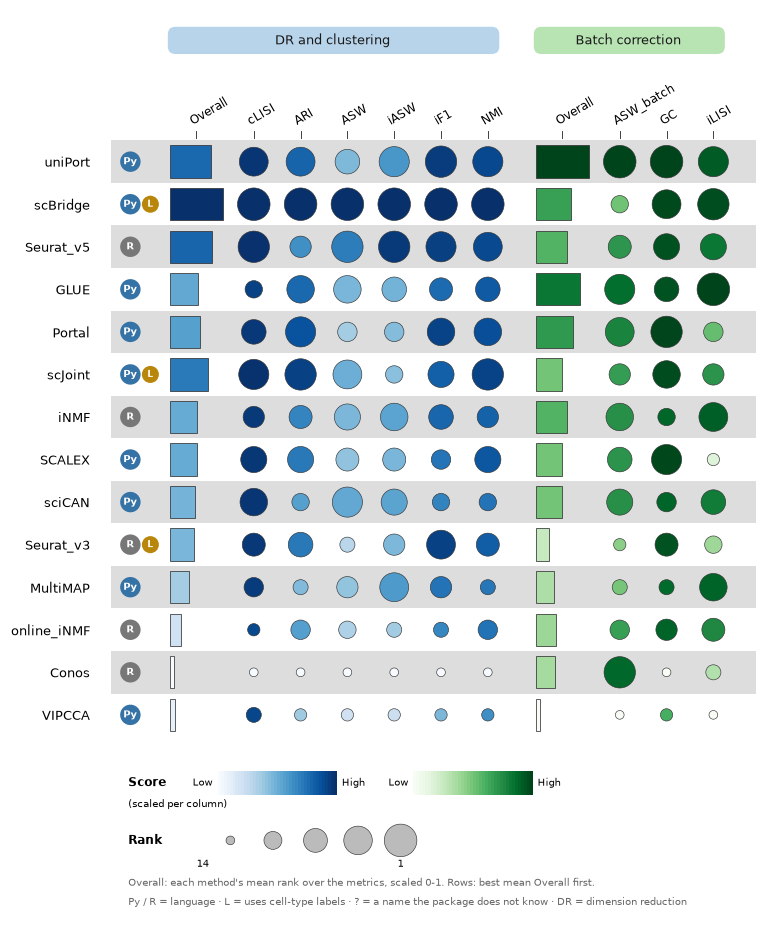

In [5]:
res.plot()